<a href="https://colab.research.google.com/github/Putra1688/PCVK25_3G_22/blob/main/Week05_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

Output :


<BarContainer object of 256 artists>

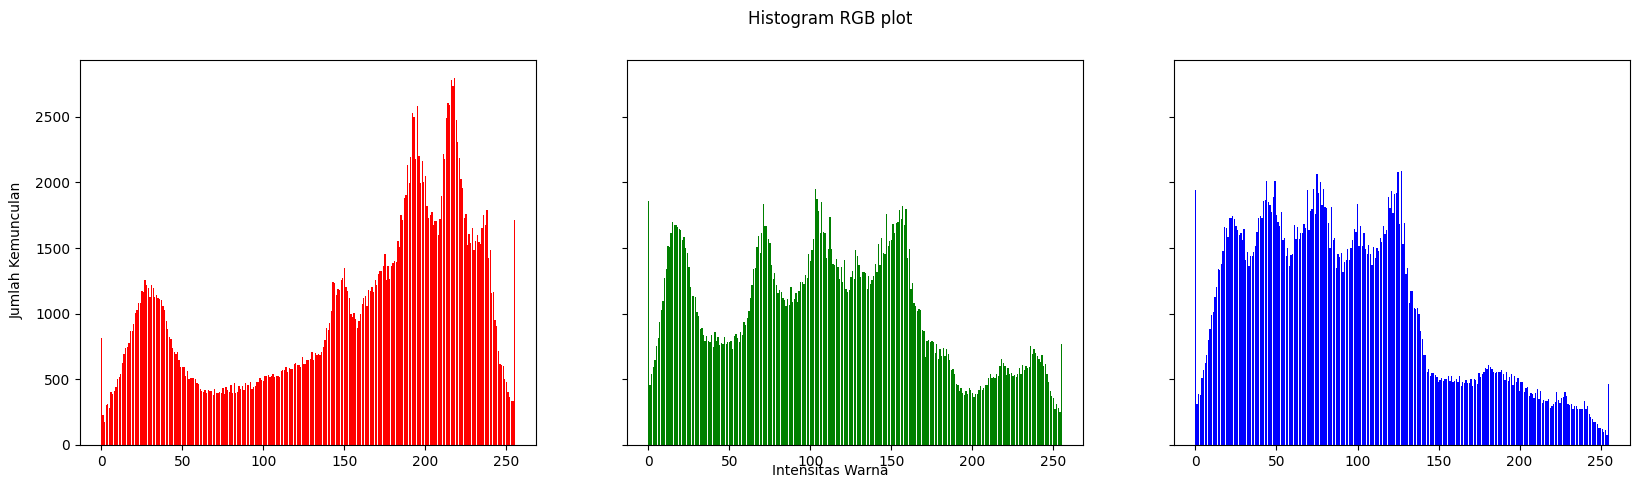

In [4]:
img = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 5/Salinan lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height) :
  for x in range(0, width) :
    red [img[y, x, 0]] += 1
    green [img[y, x, 1]] += 1
    blue [img[y, x, 2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
print('Output :')
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.05, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

## **PERTANYAAN PRAKTIKUM D1**

**1. Histogram dengan NumPy `histogram`**

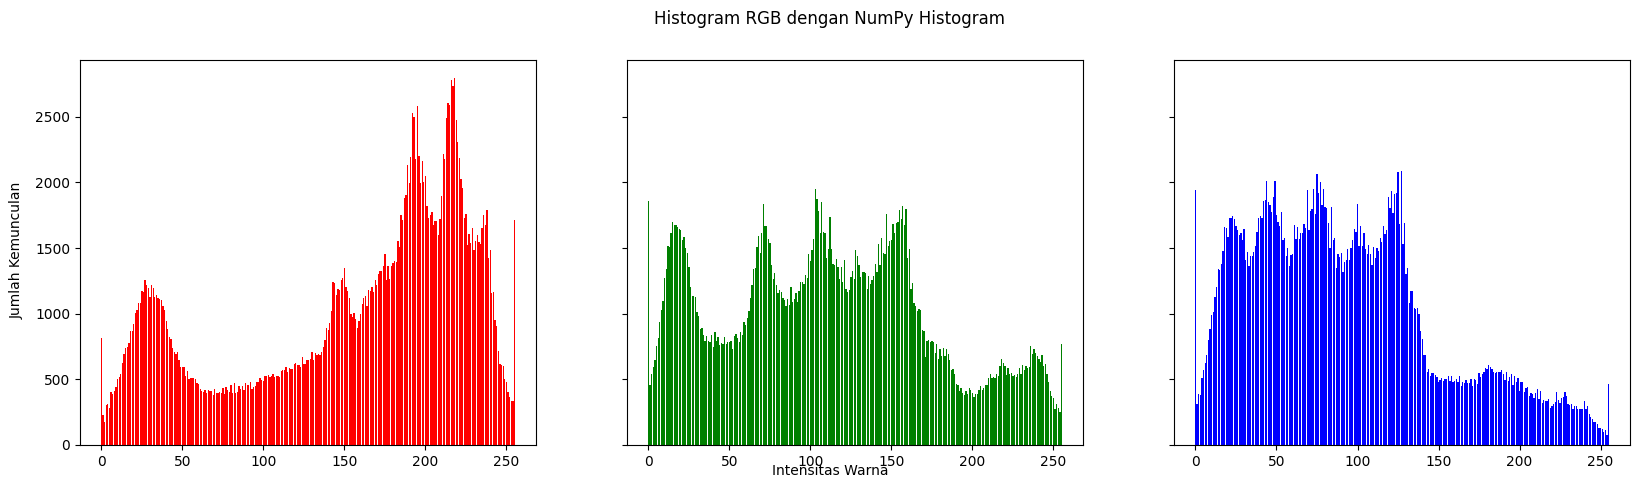

In [5]:

r = img[:, :, 0].ravel()
g = img[:, :, 1].ravel()
b = img[:, :, 2].ravel()

# Hitung histogram dengan NumPy
hist_r, bins_r = np.histogram(r, bins=256, range=(0, 256))
hist_g, bins_g = np.histogram(g, bins=256, range=(0, 256))
hist_b, bins_b = np.histogram(b, bins=256, range=(0, 256))

# Plot hasil histogram
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB dengan NumPy Histogram')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.05, 'Intensitas Warna', ha='center')

axs[0].bar(np.arange(256), hist_r, color='red')
axs[1].bar(np.arange(256), hist_g, color='green')
axs[2].bar(np.arange(256), hist_b, color='blue')

plt.show()

Perbandingan hasil dengan metode manual:

- Bentuk grafik sama persis, karena np.histogram secara otomatis menghitung jumlah kemunculan tiap intensitas piksel.

- Bedanya hanya di cara perhitungan: manual looping lebih lama, np.histogram lebih efisien.

**2. Histogram dengan gambar KTM lama.jpg**

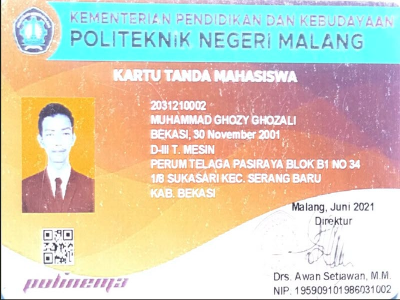

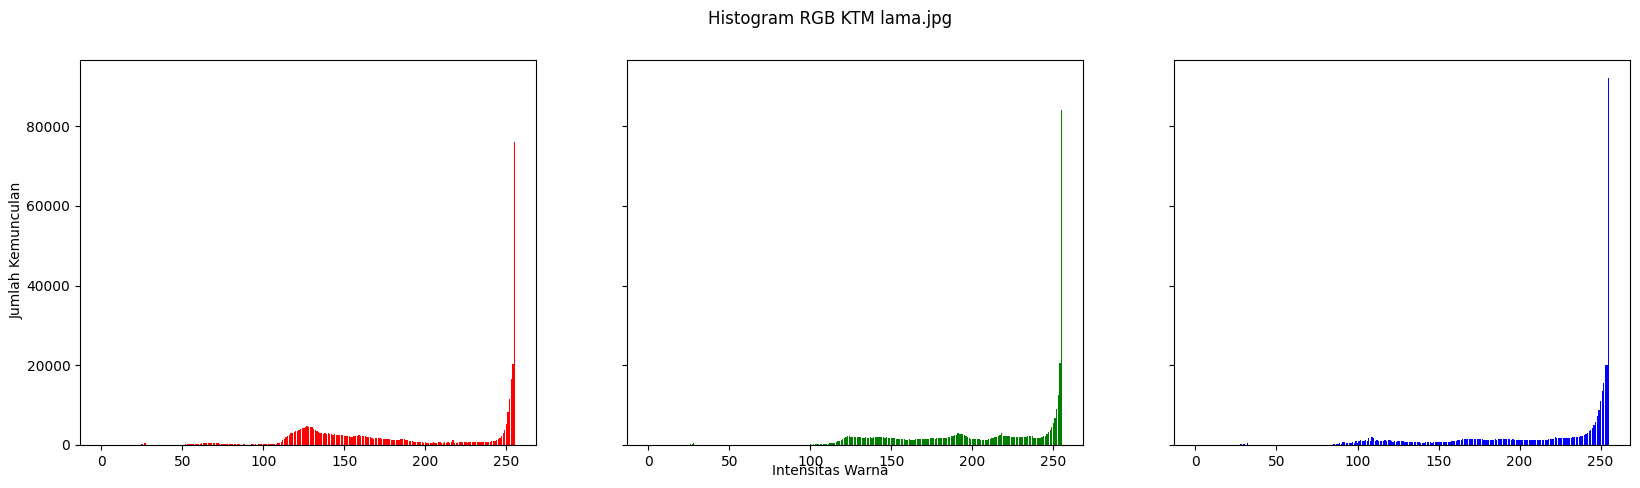

In [6]:
# Baca gambar KTM
img2 = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 5/Salinan KTM lama.jpg')
img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)
ktm = cv.resize(img2, (400, 300))
cv2_imshow(ktm)

# Pisahkan channel
r2 = img2[:, :, 0].ravel()
g2 = img2[:, :, 1].ravel()
b2 = img2[:, :, 2].ravel()

# Hitung histogram
hist_r2, _ = np.histogram(r2, bins=256, range=(0, 256))
hist_g2, _ = np.histogram(g2, bins=256, range=(0, 256))
hist_b2, _ = np.histogram(b2, bins=256, range=(0, 256))

# Plot
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB KTM lama.jpg')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.05, 'Intensitas Warna', ha='center')

axs[0].bar(np.arange(256), hist_r2, color='red')
axs[1].bar(np.arange(256), hist_g2, color='green')
axs[2].bar(np.arange(256), hist_b2, color='blue')

plt.show()

Analisis distribusi intensitas (KTM lama.jpg):

- Cenderung gelap → jika histogram lebih banyak di intensitas rendah (0–100).

- Cenderung terang → jika histogram lebih banyak di intensitas tinggi (150–255).

- Kontras rendah → jika histogram hanya menumpuk di kisaran sempit (misalnya hanya di 100–150).

- Kontras baik (seimbang) → jika histogram tersebar merata dari gelap hingga terang.

Bisa disimpulkan bahwa gelap/terang/kontras rendah tergantung hasil plot histogram dari KTM lama.jpg

## **PERCOBAAN PRAKTIKUM D2**
Histogram Equalization

Gambar sebelum dan sesudah histogram equalization:


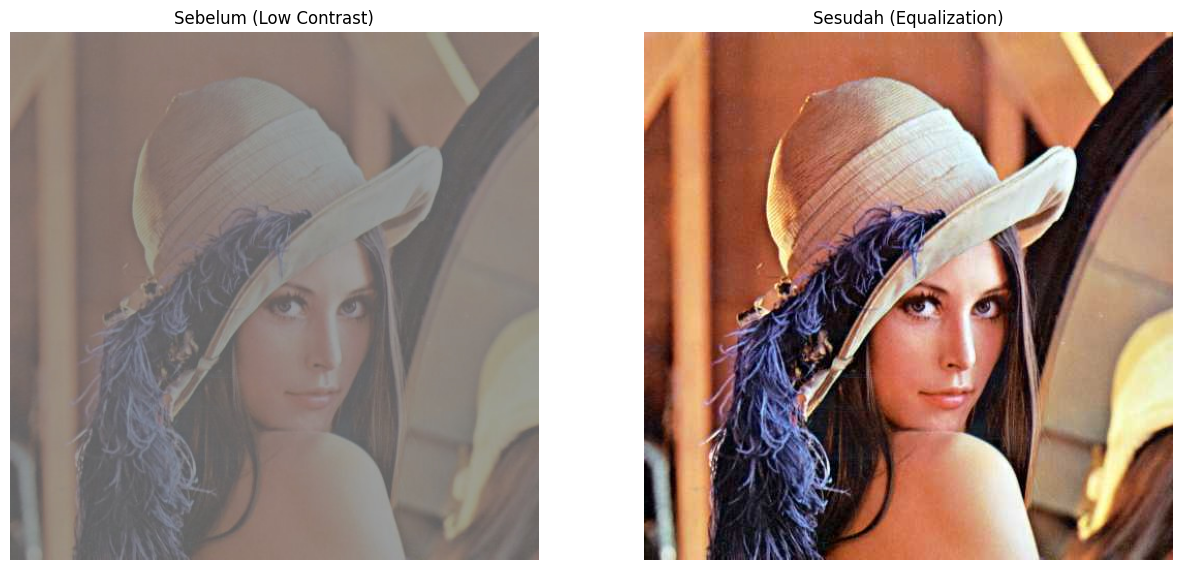

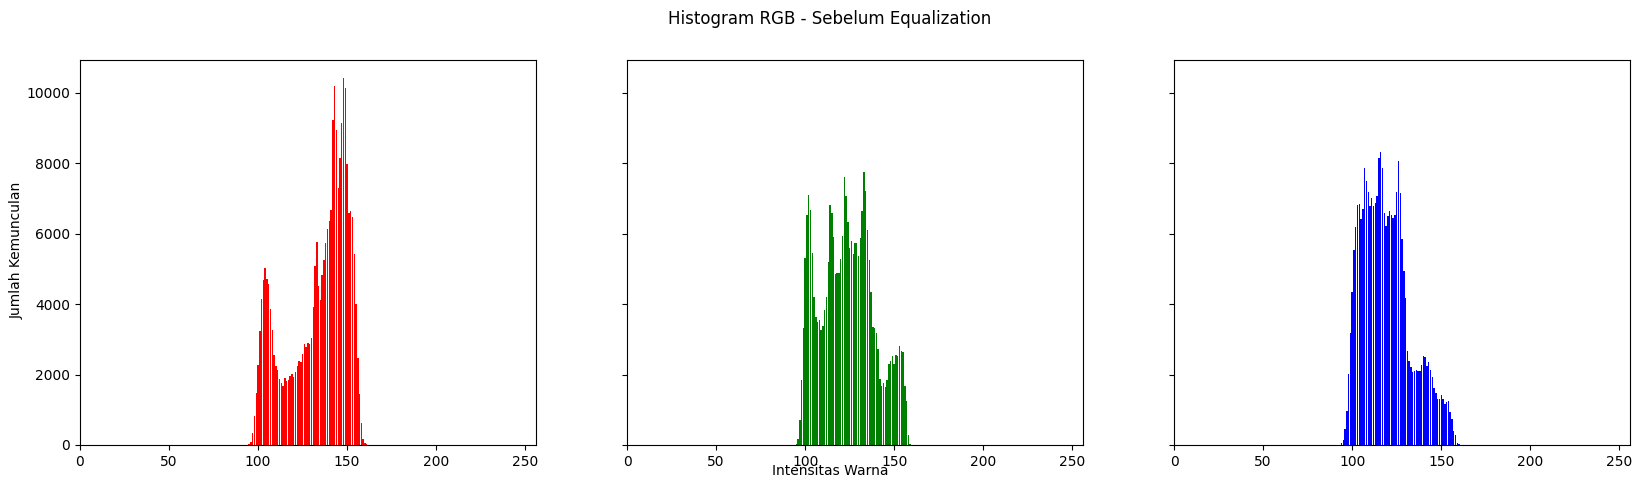

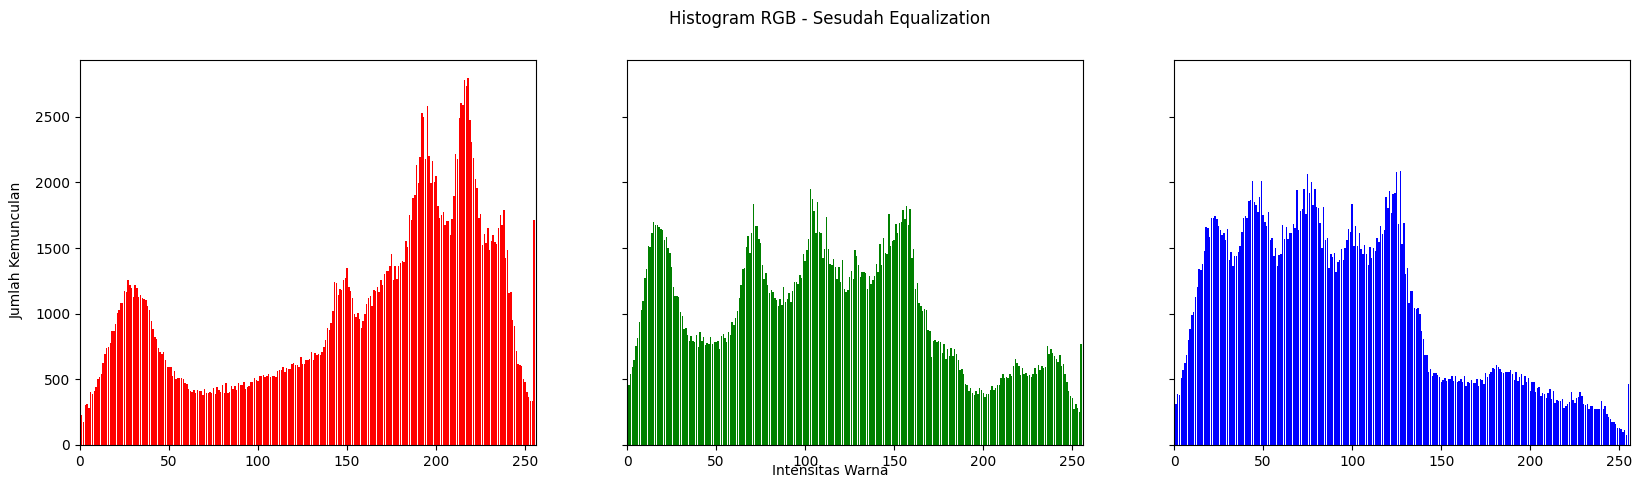

In [19]:
# 1. Start program
# 2. Input image
lena_lc = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 5/Salinan lena_lc.jpg')
lena = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 5/Salinan lena.jpg')

lena_lc_rgb = cv.cvtColor(lena_lc, cv.COLOR_BGR2RGB)
lena_rgb = cv.cvtColor(lena, cv.COLOR_BGR2RGB)

# 1. Frekuensi
hist_r, _ = np.histogram(lena_lc_rgb[:, :, 0].ravel(), bins=256, range=(0,256))
hist_g, _ = np.histogram(lena_lc_rgb[:, :, 1].ravel(), bins=256, range=(0,256))
hist_b, _ = np.histogram(lena_lc_rgb[:, :, 2].ravel(), bins=256, range=(0,256))

# 2. Kumulatif
cdf_r = hist_r.cumsum()
cdf_g = hist_g.cumsum()
cdf_b = hist_b.cumsum()

# 3. Normalisasi
cdf_r_norm = cdf_r / cdf_r[-1]
cdf_g_norm = cdf_g / cdf_g[-1]
cdf_b_norm = cdf_b / cdf_b[-1]

# 4. Rumus Kx (mapping ke 0-255)
kx_r = np.floor(255 * cdf_r_norm).astype('uint8')
kx_g = np.floor(255 * cdf_g_norm).astype('uint8')
kx_b = np.floor(255 * cdf_b_norm).astype('uint8')

# plot histogram RGB
def plot_rgb_hist(img, title):
    colors = ('red', 'green', 'blue')
    fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
    fig.suptitle(title)
    fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
    fig.text(0.5, 0.05, 'Intensitas Warna', ha='center')

    for i, col in enumerate(colors):
        hist, bins = np.histogram(img[:, :, i].ravel(), bins=256, range=(0, 256))
        axs[i].bar(np.arange(256), hist, color=col)
        axs[i].set_xlim([0, 256])

    plt.show()

print("Gambar sebelum dan sesudah histogram equalization:")
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(lena_lc_rgb)
plt.title("Sebelum (Low Contrast)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(lena_rgb)
plt.title("Sesudah (Equalization)")
plt.axis("off")
plt.show()

# Histogram sebelum
plot_rgb_hist(lena_lc_rgb, "Histogram RGB - Sebelum Equalization")

# Histogram sesudah
plot_rgb_hist(lena_rgb, "Histogram RGB - Sesudah Equalization")

Histogram citra dengan `equalizeHist`

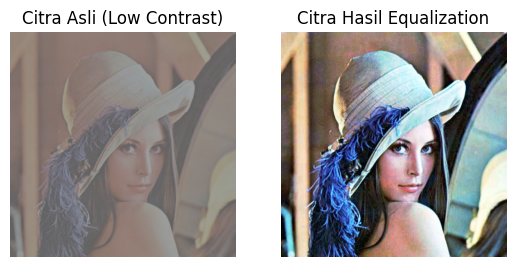

In [28]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 5/Salinan lena_lc.jpg')   # gambar low contrast
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Pisah channel
b, g, r = cv2.split(image)

# Histogram Equalization per channel
b_equalized = cv2.equalizeHist(b)
g_equalized = cv2.equalizeHist(g)
r_equalized = cv2.equalizeHist(r)

# Gabungkan kembali channel yang sudah di equalize
equalized_img = cv2.merge((b_equalized, g_equalized, r_equalized))
equalized_rgb = cv2.cvtColor(equalized_img, cv2.COLOR_BGR2RGB)

# Tampilkan hasil
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Citra Asli (Low Contrast)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized_rgb)
plt.title("Citra Hasil Equalization")
plt.axis("off")

plt.show()

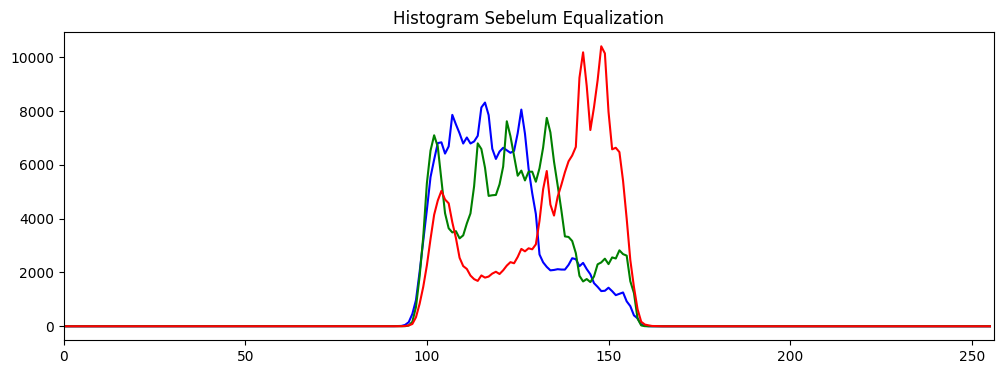

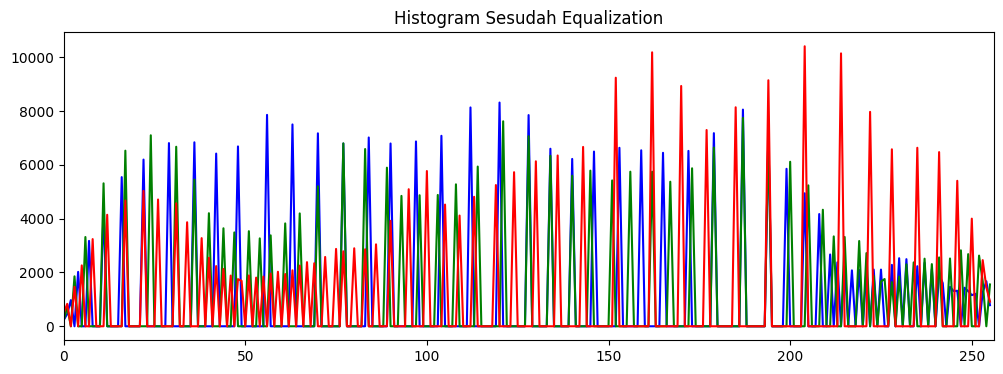

In [29]:
def plot_rgb_hist(img, title):
    colors = ('b', 'g', 'r')
    plt.figure(figsize=(12, 4))
    plt.title(title)
    for i, col in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color=col)
        plt.xlim([0, 256])
    plt.show()

# Histogram sebelum
plot_rgb_hist(image, "Histogram Sebelum Equalization")

# Histogram sesudah
plot_rgb_hist(equalized_img, "Histogram Sesudah Equalization")

## **PERTANYAAN PRAKTIKUM D2**

1. Perbandingan Citra Lena

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

lena = cv2.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 5/Salinan lena.jpg')

# Split channel
b, g, r = cv2.split(lena)

# Equalize setiap channel
b_equalized = cv2.equalizeHist(b)
g_equalized = cv2.equalizeHist(g)
r_equalized = cv2.equalizeHist(r)

# Gabung kembali
equalized_img = cv2.merge((b_equalized, g_equalized, r_equalized))

# Fungsi hitung PSNR
def calculate_psnr(original, processed):
    mse = np.mean((original - processed) ** 2)
    if mse == 0:
        return float('inf')   # identik
    max_pixel = 255.0
    psnr = 10 * np.log10((max_pixel ** 2) / mse)
    return psnr

# Hitung PSNR antara citra asli dan hasil equalization
psnr_value = calculate_psnr(lena, equalized_img)

print("Nilai PSNR antara citra asli dan hasil histogram equalization:", psnr_value, "dB")

Nilai PSNR antara citra asli dan hasil histogram equalization: 28.460093386445386 dB


Nilai PSNR yang dihasilkan bisa dikatakan cukup, tidak begitu buruk dan juga tidak terlalu baik. Bu Hani pernah menerangkan dalam pertemuan ke-tiga bahwasanya PSNR bisa dibilang bagus jika nilainya 30 dB keatas

Nilai 28.46 dB artinya citra hasil equalization berbeda cukup signifikan dari citra asli, tapi peningkatan kualitas visual (kontras dan detail) memang tujuan utamanya.

Detail baru memang muncul (terutama di area gelap dan terang), meskipun PSNR turun karena perubahan distribusi piksel.

PSNR HE vs Asli: 29.78790980979732 dB
PSNR CLAHE vs Asli: 28.432162113942667 dB


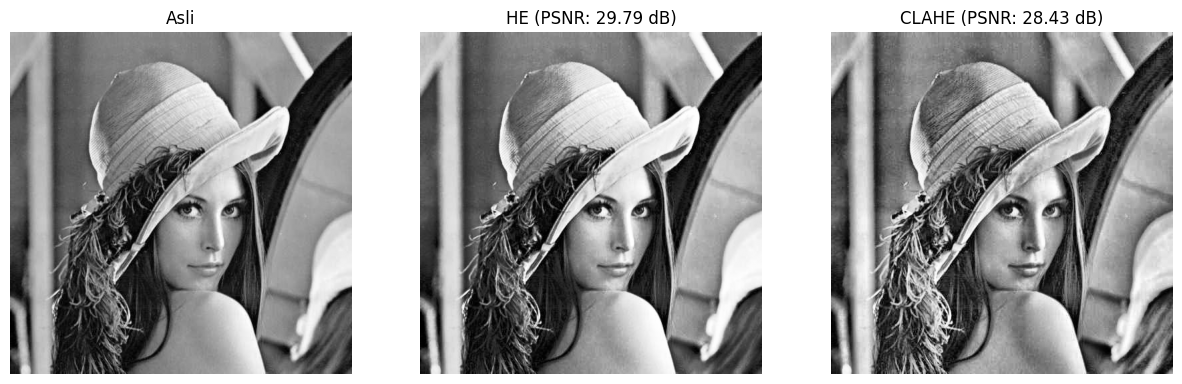

In [7]:
import math

lena = cv2.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 5/Salinan lena.jpg')

# Konversi ke grayscale untuk equalization (lebih umum)
lena_gray = cv2.cvtColor(lena, cv2.COLOR_BGR2GRAY)

# --- Histogram Equalization (HE) ---
he_img = cv2.equalizeHist(lena_gray)

# --- CLAHE ---
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_img = clahe.apply(lena_gray)

# Fungsi hitung PSNR
def psnr(original, processed):
    mse = np.mean((original - processed) ** 2)
    if mse == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    return 20 * math.log10(PIXEL_MAX / math.sqrt(mse))

# Hitung PSNR
psnr_he = psnr(lena_gray, he_img)
psnr_clahe = psnr(lena_gray, clahe_img)

print("PSNR HE vs Asli:", psnr_he, "dB")
print("PSNR CLAHE vs Asli:", psnr_clahe, "dB")

# --- Tampilkan hasil ---
plt.figure(figsize=(15,8))

plt.subplot(1,3,1)
plt.imshow(lena_gray, cmap='gray')
plt.title("Asli")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(he_img, cmap='gray')
plt.title(f"HE (PSNR: {psnr_he:.2f} dB)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(clahe_img, cmap='gray')
plt.title(f"CLAHE (PSNR: {psnr_clahe:.2f} dB)")
plt.axis("off")

plt.show()

2. Citra KTM lama

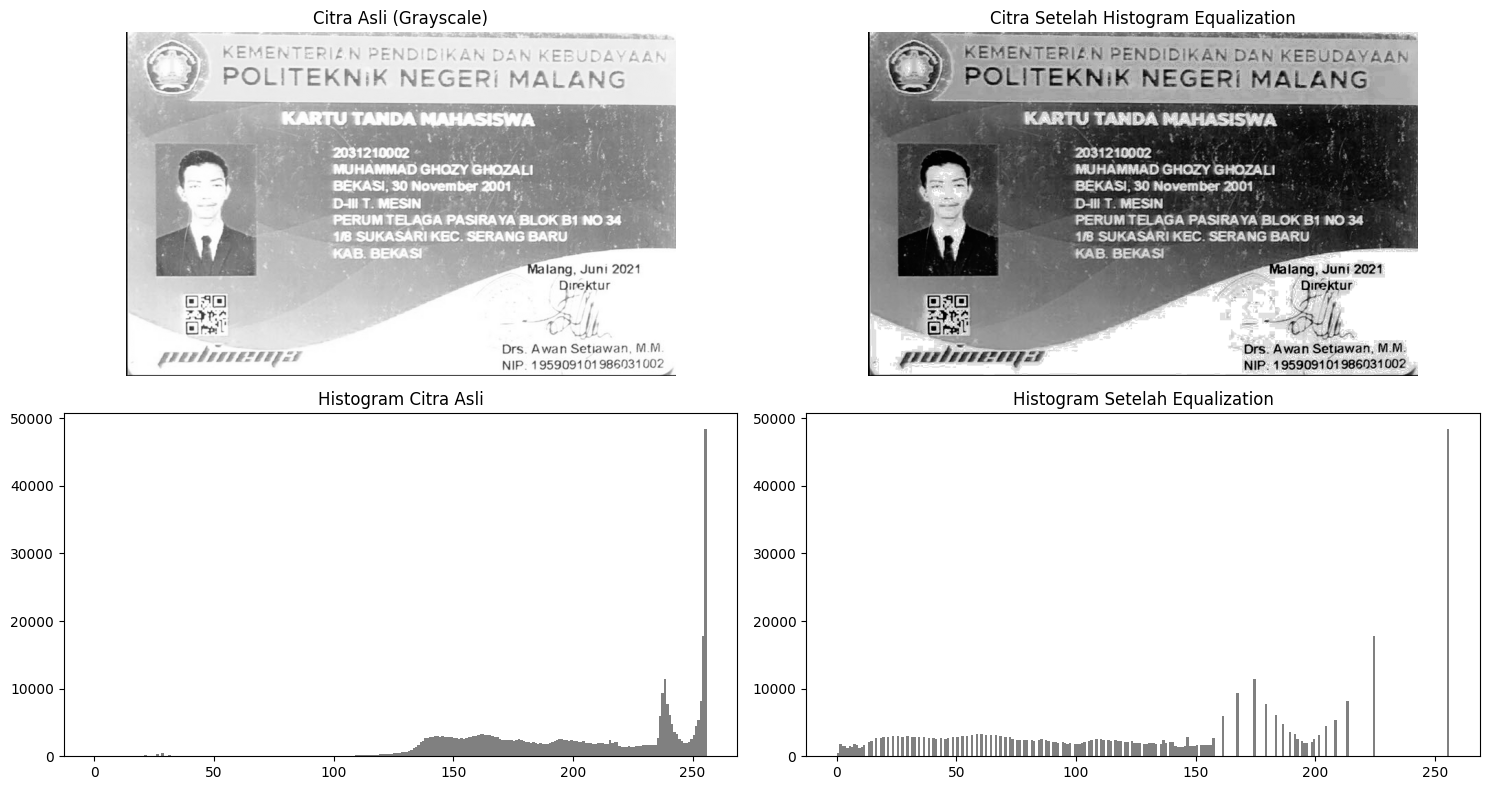

In [11]:
ktm = cv2.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 5/Salinan KTM lama.jpg')
ktm_gray = cv2.cvtColor(ktm, cv2.COLOR_BGR2GRAY)

# Histogram Equalization
ktm_eq = cv2.equalizeHist(ktm_gray)

# Plot hasil
plt.figure(figsize=(15,8))

# --- Citra asli ---
plt.subplot(2,2,1)
plt.imshow(ktm_gray, cmap='gray')
plt.title("Citra Asli (Grayscale)")
plt.axis("off")

# --- Citra hasil equalization ---
plt.subplot(2,2,2)
plt.imshow(ktm_eq, cmap='gray')
plt.title("Citra Setelah Histogram Equalization")
plt.axis("off")

# --- Histogram asli ---
plt.subplot(2,2,3)
plt.hist(ktm_gray.ravel(), bins=256, range=[0,256], color='gray')
plt.title("Histogram Citra Asli")

# --- Histogram hasil equalization ---
plt.subplot(2,2,4)
plt.hist(ktm_eq.ravel(), bins=256, range=[0,256], color='gray')
plt.title("Histogram Setelah Equalization")

plt.tight_layout()
plt.show()

Citra asli (KTM lama):

- Cenderung gelap atau kontras rendah.

- Tulisan/teks (misalnya nama, NIM, keterangan) kurang jelas terbaca.
<hr>

Citra setelah Histogram Equalization:

- Kontras meningkat → detail wajah, teks, dan background lebih jelas.

- Histogram lebih tersebar merata di rentang intensitas 0–255.

- Informasi lebih mudah terbaca (teks lebih kontras dengan background).
<hr>
Apakah kualitas meningkat atau keras?

- Kalau citra asli sangat redup, maka hasil equalization meningkatkan kualitas informasi (teks, wajah jadi jelas).

- Tapi jika citra sudah cukup terang, hasil equalization bisa terlihat agak “keras” (kontras terlalu tinggi, noise ikut muncul).

## **TUGAS PRAKTIKUM *DHITERING***

1. Proses dithering Floyd–Steinberg pada lena.jpg

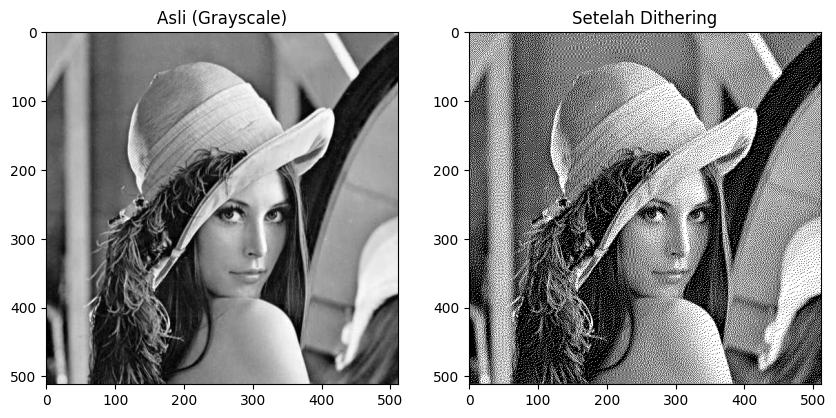

In [12]:
def floyd_steinberg_dithering(img):
    h, w = img.shape
    output = img.copy().astype(float)

    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = output[y, x]
            new_pixel = 255 if old_pixel > 127 else 0
            output[y, x] = new_pixel
            error = old_pixel - new_pixel

            # Sebarkan error ke pixel tetangga
            output[y, x+1] += error * 7/16
            output[y+1, x-1] += error * 3/16
            output[y+1, x] += error * 5/16
            output[y+1, x+1] += error * 1/16

    return np.clip(output, 0, 255).astype(np.uint8)



lena = cv2.imread("/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 5/Salinan lena.jpg", cv2.IMREAD_GRAYSCALE)
lena_dithered = floyd_steinberg_dithering(lena)

# Tampilkan hasil
plt.figure(figsize=(10,5))
plt.subplot(1,2,1), plt.imshow(lena, cmap="gray"), plt.title("Asli (Grayscale)")
plt.subplot(1,2,2), plt.imshow(lena_dithered, cmap="gray"), plt.title("Setelah Dithering")
plt.show()


2. Convert ke grayscale → Histogram Equalization → Dithering pada lena_lc.jpg.

/tmp/ipython-input-2666023822.py:44: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(3,2,3), plt.hist(lena_lc.ravel(), 256, [0,256]), plt.title("Histogram Asli")
/tmp/ipython-input-2666023822.py:45: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(3,2,4), plt.hist(lena_eq.ravel(), 256, [0,256]), plt.title("Histogram Equalization")


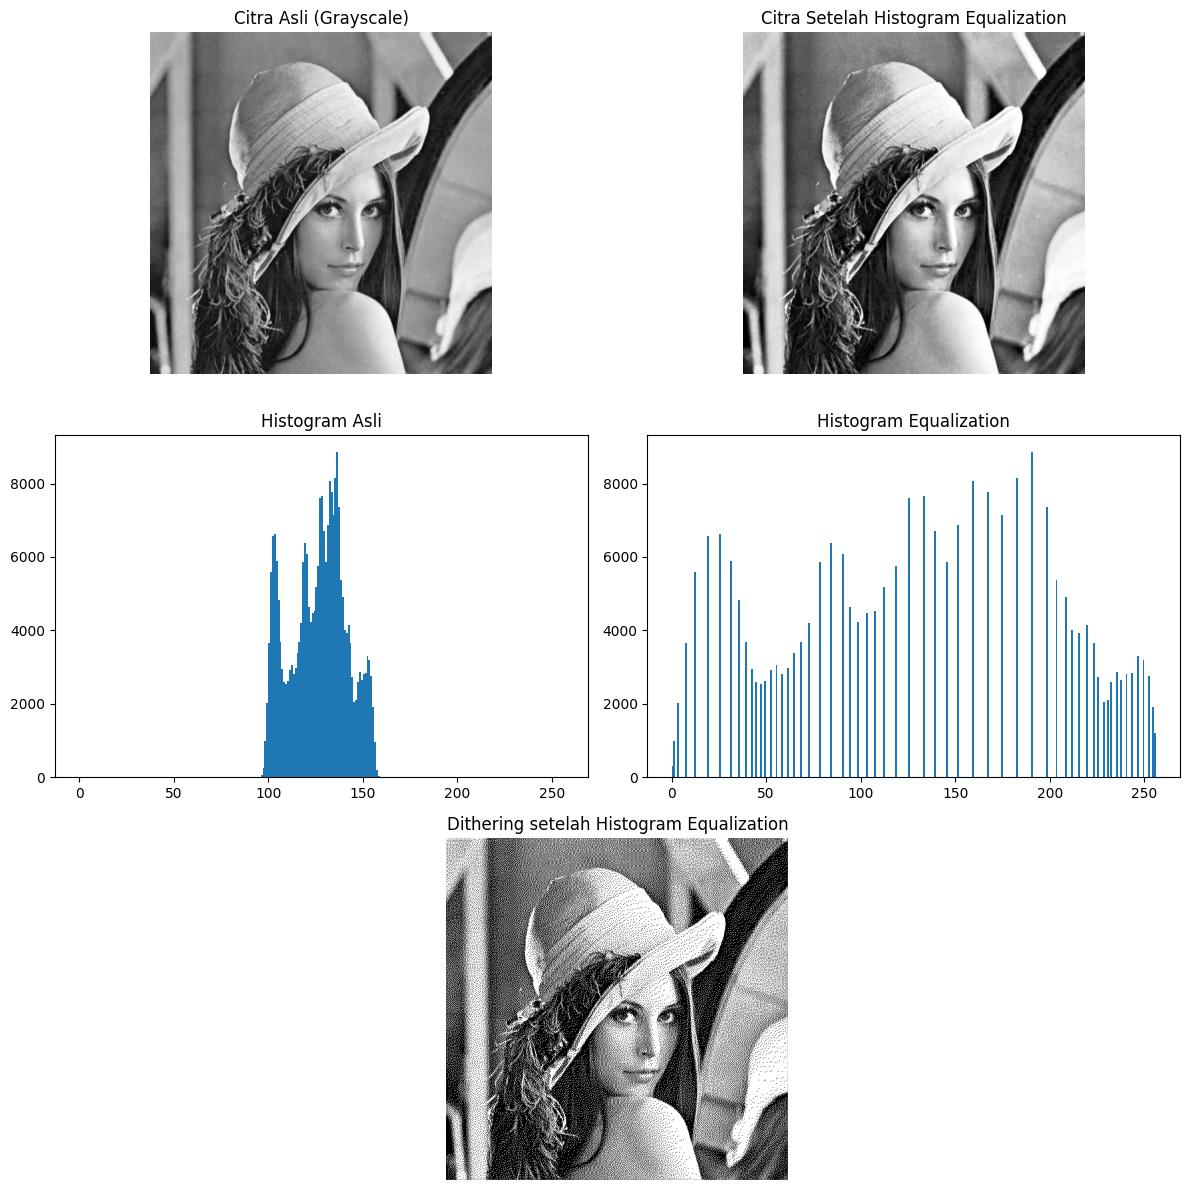

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Fungsi dithering Floyd–Steinberg
def floyd_steinberg_dithering(img):
    h, w = img.shape
    output = img.copy().astype(float)

    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = output[y, x]
            new_pixel = 255 if old_pixel > 127 else 0
            output[y, x] = new_pixel
            error = old_pixel - new_pixel

            # Sebarkan error ke pixel tetangga
            output[y, x+1] += error * 7/16
            output[y+1, x-1] += error * 3/16
            output[y+1, x] += error * 5/16
            output[y+1, x+1] += error * 1/16

    return np.clip(output, 0, 255).astype(np.uint8)

# Load citra lena_lc.jpg (low contrast)
lena_lc = cv2.imread("/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 5/Salinan lena_lc.jpg", cv2.IMREAD_GRAYSCALE)

# Histogram Equalization
lena_eq = cv2.equalizeHist(lena_lc)

# Hasil dithering setelah equalization
lena_eq_dithered = floyd_steinberg_dithering(lena_eq)

# ================== PLOT ==================
plt.figure(figsize=(12,12))

# Baris 1: citra asli & equalization
plt.subplot(3,2,1), plt.imshow(lena_lc, cmap="gray"), plt.title("Citra Asli (Grayscale)")
plt.axis("off")
plt.subplot(3,2,2), plt.imshow(lena_eq, cmap="gray"), plt.title("Citra Setelah Histogram Equalization")
plt.axis("off")

# Baris 2: histogram sebelum & sesudah
plt.subplot(3,2,3), plt.hist(lena_lc.ravel(), 256, [0,256]), plt.title("Histogram Asli")
plt.subplot(3,2,4), plt.hist(lena_eq.ravel(), 256, [0,256]), plt.title("Histogram Equalization")

# Baris 3: hasil dithering setelah equalization (full span)
plt.subplot(3,1,3), plt.imshow(lena_eq_dithered, cmap="gray"), plt.title("Dithering setelah Histogram Equalization")
plt.axis("off")

plt.tight_layout()
plt.show()
